# Mass-Action CRN Generator: Illustration

This notebook demonstrates the random mass-action CRN generator. It samples
random network topologies, visualizes their structure, and simulates SSA
trajectories to show the diversity of dynamics that arise from combinatorial
variation in simple mass-action networks.

All CRNs use at most 3 species and 6 reactions with mass-action or
constant-rate (zeroth-order) kinetics.


In [1]:
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules
if COLAB:
    import subprocess, os
    _CLONE_DIR = "/content/CRN_Surrogate"
    if not os.path.exists(_CLONE_DIR):
        print("Colab detected, cloning repo and installing...")
        subprocess.check_call(
            ["git", "clone", "-q",
             "https://github.com/Mijan/CRN_Surrogate.git", _CLONE_DIR])
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "-e", _CLONE_DIR])
    sys.path.insert(0, _CLONE_DIR)
else:
    sys.path.insert(0, str(Path("../..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 1. Sample Random Topologies

We sample 6 random mass-action topologies and print their reaction structure.

In [2]:
from crn_surrogate.data.generation.mass_action_generator import (
    MassActionCRNGenerator,
    MassActionGeneratorConfig,
    RandomTopologyConfig,
)
from crn_surrogate.data.generation.mass_action_topology import MassActionTopology

config = MassActionGeneratorConfig(
    topology=RandomTopologyConfig(
        n_species_range=(1, 3),
        n_reactions_range=(2, 6),
        max_reactant_order=2,
        max_product_count=2,
    ),
    rate_constant_range=(0.01, 10.0),
)
gen = MassActionCRNGenerator(config)

# Sample 6 CRNs
torch.manual_seed(42)
topologies = gen._topology_sampler.sample_batch(6)
crns = [gen.sample_from_topology(t) for t in topologies]

for i, (topo, crn) in enumerate(zip(topologies, crns)):
    print(f"=== CRN {i}: {topo.n_species} species, {topo.n_reactions} reactions ===")
    print(topo.summary())
    print()


=== CRN 0: 1 species, 4 reactions ===
MassActionTopology: 1 species, 4 reactions
  R0: S0 -> 2S0
  R1: 2S0 -> S0
  R2: 2S0 -> 0
  R3: 0 -> S0

=== CRN 1: 2 species, 6 reactions ===
MassActionTopology: 2 species, 6 reactions
  R0: S1 -> S0
  R1: 0 -> S0
  R2: S0 -> S1
  R3: 2S1 -> 0
  R4: S0 + S1 -> 0
  R5: 0 -> S1

=== CRN 2: 1 species, 4 reactions ===
MassActionTopology: 1 species, 4 reactions
  R0: S0 -> 0
  R1: 2S0 -> 0
  R2: S0 -> 2S0
  R3: 0 -> S0

=== CRN 3: 2 species, 6 reactions ===
MassActionTopology: 2 species, 6 reactions
  R0: S0 -> 0
  R1: S1 -> 0
  R2: S0 + S1 -> 0
  R3: S1 -> S0 + S1
  R4: S0 -> S0 + S1
  R5: 0 -> S0

=== CRN 4: 2 species, 5 reactions ===
MassActionTopology: 2 species, 5 reactions
  R0: 0 -> S0
  R1: S0 -> S1
  R2: 0 -> S1
  R3: S0 -> 0
  R4: S0 + S1 -> 0

=== CRN 5: 3 species, 4 reactions ===
MassActionTopology: 3 species, 4 reactions
  R0: 0 -> S1
  R1: S0 + S2 -> S2
  R2: S1 -> 0
  R3: S2 -> 0



## 2. Visualize Network Topologies

Each CRN is a bipartite graph: circles are species, squares are reactions.
Edges show which species participate in which reactions. Edge color indicates
the role: blue for reactants (consumed), red for products (produced),
gray for catalytic dependencies (species affects rate but isn't consumed).

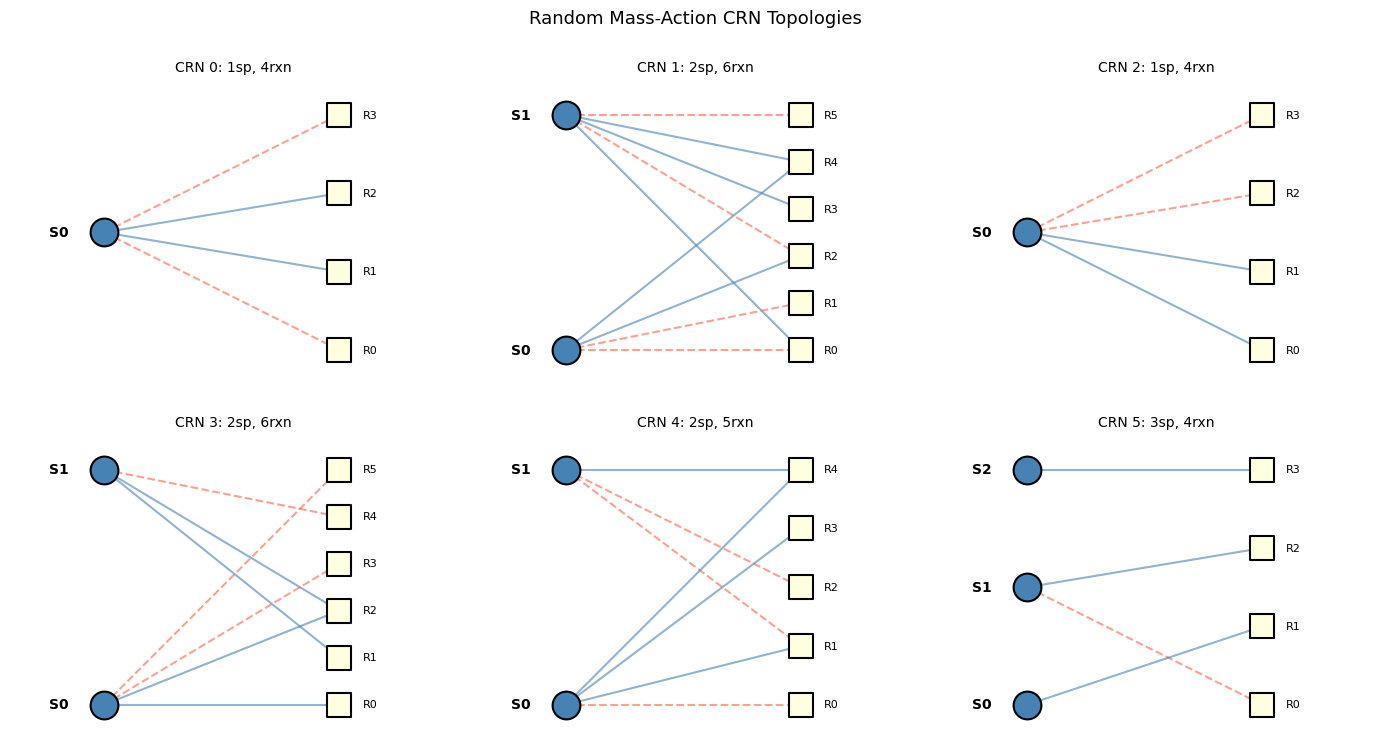

In [3]:
def plot_crn_topology(crn, ax, title=""):
    """Draw a CRN as a bipartite graph on the given axes."""
    n_s = crn.n_species
    n_r = crn.n_reactions
    names = crn.species_names if hasattr(crn, "species_names") and crn.species_names else [f"S{s}" for s in range(n_s)]

    # Layout: species on the left, reactions on the right
    species_y = np.linspace(0, 1, n_s) if n_s > 1 else [0.5]
    reaction_y = np.linspace(0, 1, n_r) if n_r > 1 else [0.5]
    species_x = 0.0
    reaction_x = 1.0

    # Draw edges
    for r, rxn in enumerate(crn.reactions):
        stoich = rxn.stoichiometry
        for s in range(n_s):
            v = stoich[s].item()
            if v < 0:
                # Reactant: consumed
                ax.plot([species_x, reaction_x], [species_y[s], reaction_y[r]],
                        color="steelblue", alpha=0.6, lw=1.5, zorder=1)
            elif v > 0:
                # Product: produced
                ax.plot([species_x, reaction_x], [species_y[s], reaction_y[r]],
                        color="tomato", alpha=0.6, lw=1.5, linestyle="--", zorder=1)

    # Draw species nodes (circles)
    for s in range(n_s):
        ax.scatter(species_x, species_y[s], s=400, c="steelblue",
                   edgecolors="black", linewidths=1.5, zorder=3)
        ax.text(species_x - 0.15, species_y[s], names[s],
                ha="right", va="center", fontsize=10, fontweight="bold")

    # Draw reaction nodes (squares)
    for r in range(n_r):
        ax.scatter(reaction_x, reaction_y[r], s=300, c="lightyellow",
                   edgecolors="black", linewidths=1.5, marker="s", zorder=3)
        ax.text(reaction_x + 0.1, reaction_y[r], f"R{r}",
                ha="left", va="center", fontsize=8)

    ax.set_xlim(-0.4, 1.5)
    ax.set_ylim(-0.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (crn, ax) in enumerate(zip(crns, axes.flat)):
    plot_crn_topology(crn, ax, title=f"CRN {i}: {crn.n_species}sp, {crn.n_reactions}rxn")

plt.suptitle("Random Mass-Action CRN Topologies", fontsize=13)
plt.tight_layout()
plt.show()


## 3. SSA Trajectories

For each CRN, we simulate M=20 independent Gillespie trajectories from a
random initial state. The diversity of dynamics (relaxation, oscillation,
extinction, multi-stability) emerges naturally from the random topologies.

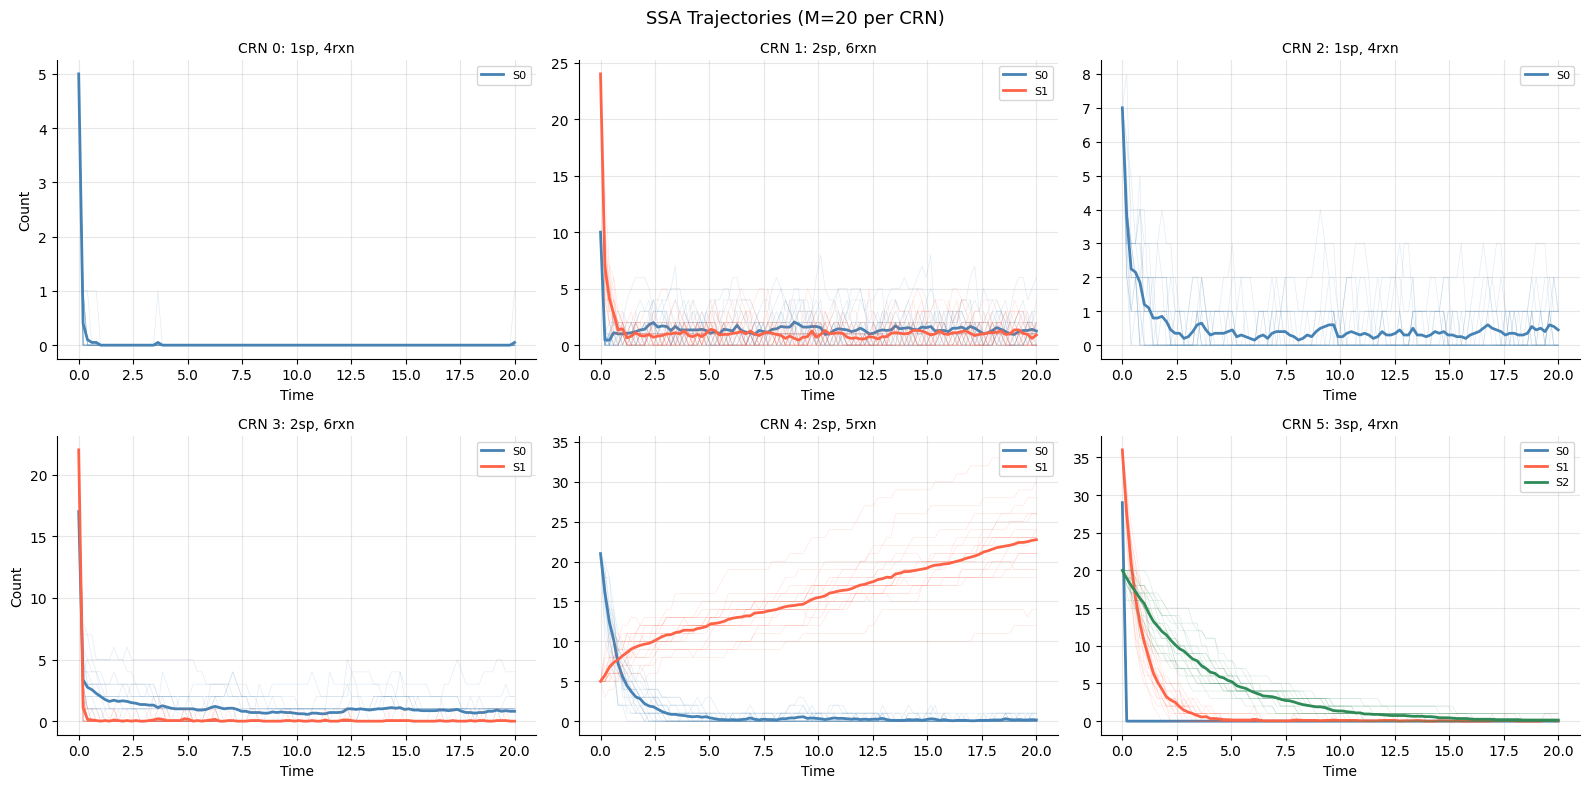

In [4]:
from crn_surrogate.simulation.gillespie import GillespieSSA
from crn_surrogate.simulation.trajectory import Trajectory

ssa = GillespieSSA()
M = 20
T_MAX = 20.0
N_GRID = 100
time_grid = torch.linspace(0.0, T_MAX, N_GRID)
t_np = time_grid.numpy()

# Color palette for species
SPECIES_COLORS = ["steelblue", "tomato", "seagreen"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, (crn, ax) in enumerate(zip(crns, axes.flat)):
    init_state = gen.sample_initial_state(crn, mean_molecules=10.0, spread=2.0)

    trajs = ssa.simulate_batch(
        stoichiometry=crn.stoichiometry_matrix,
        propensity_fn=crn.evaluate_propensities,
        initial_state=init_state,
        t_max=T_MAX,
        n_trajectories=M,
    )
    tensor = Trajectory.stack_on_grid(trajs, time_grid)  # (M, T, n_species)

    names = crn.species_names if hasattr(crn, "species_names") and crn.species_names else [f"S{s}" for s in range(crn.n_species)]

    for s in range(crn.n_species):
        color = SPECIES_COLORS[s % len(SPECIES_COLORS)]
        # Individual trajectories
        for m in range(M):
            ax.plot(t_np, tensor[m, :, s].numpy(), color=color, alpha=0.15, lw=0.5)
        # Mean
        ax.plot(t_np, tensor[:, :, s].mean(dim=0).numpy(),
                color=color, lw=2, label=names[s])

    ax.set_title(f"CRN {i}: {crn.n_species}sp, {crn.n_reactions}rxn", fontsize=10)
    ax.set_xlabel("Time")
    if i % 3 == 0:
        ax.set_ylabel("Count")
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("SSA Trajectories (M=20 per CRN)", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Named Topologies as Special Cases

The well-known motifs (birth-death, auto-catalysis, Lotka-Volterra, enzymatic
catalysis) are specific instances of mass-action topologies. They can be
instantiated with arbitrary rate constants via `topology.to_crn(rates)`.

MassActionTopology: 1 species, 2 reactions
  birth: 0 -> A
  death: A -> 0

MassActionTopology: 1 species, 3 reactions
  basal_production: 0 -> A
  autocatalysis: A -> 2A
  degradation: A -> 0

MassActionTopology: 2 species, 3 reactions
  prey_birth: prey -> 2prey
  predation: prey + predator -> 2predator
  predator_death: predator -> 0

MassActionTopology: 4 species, 5 reactions
  binding: S + E -> C
  unbinding: C -> S + E
  catalysis: C -> E + P
  substrate_input: 0 -> S
  product_degradation: P -> 0



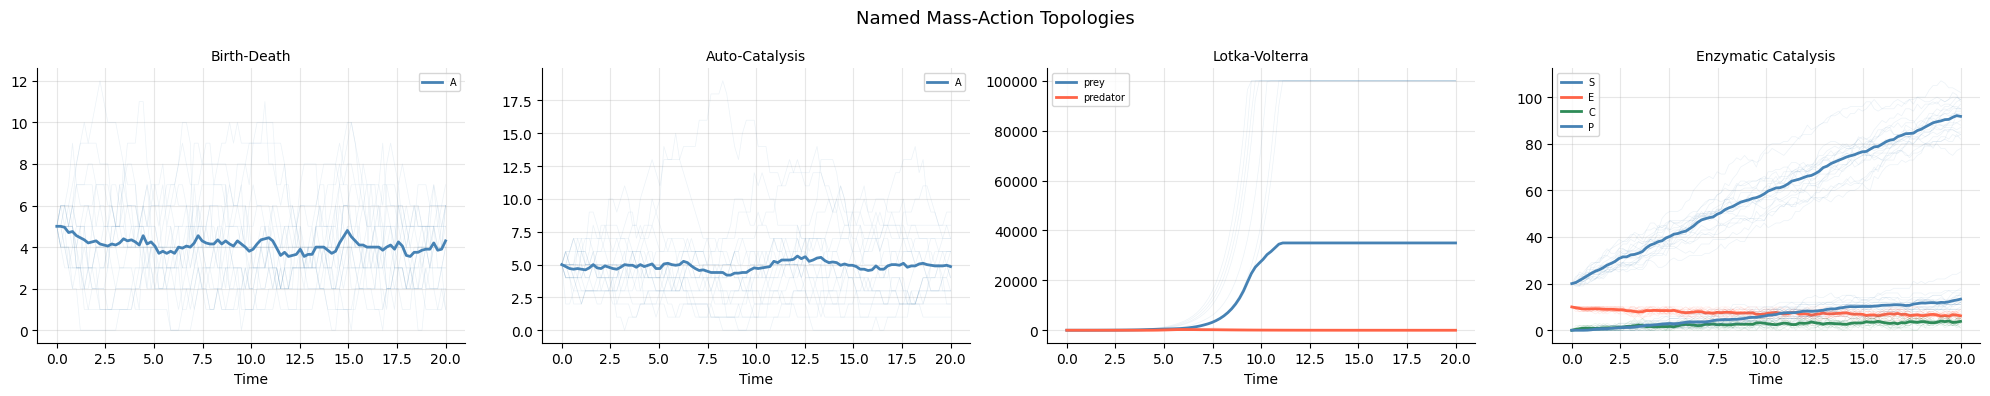

In [5]:
from crn_surrogate.data.generation.mass_action_topology import (
    birth_death_topology,
    auto_catalysis_topology,
    lotka_volterra_topology,
    enzymatic_catalysis_topology,
)

named = [
    ("Birth-Death", birth_death_topology(), [2.0, 0.5]),
    ("Auto-Catalysis", auto_catalysis_topology(), [1.0, 0.1, 0.3]),
    ("Lotka-Volterra", lotka_volterra_topology(), [1.0, 0.01, 0.5]),
    ("Enzymatic Catalysis", enzymatic_catalysis_topology(), [0.01, 1.0, 0.5, 5.0, 0.1]),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, topo, rates) in zip(axes, named):
    crn = topo.to_crn(rates)
    init = torch.zeros(crn.n_species)
    if crn.n_species >= 1:
        init[0] = 5.0
    if crn.n_species >= 2:
        init[1] = 5.0
    if crn.n_species == 4:
        init = torch.tensor([20.0, 10.0, 0.0, 0.0])

    trajs = ssa.simulate_batch(
        stoichiometry=crn.stoichiometry_matrix,
        propensity_fn=crn.evaluate_propensities,
        initial_state=init,
        t_max=T_MAX,
        n_trajectories=M,
    )
    tensor = Trajectory.stack_on_grid(trajs, time_grid)
    sp_names = crn.species_names if hasattr(crn, "species_names") and crn.species_names else [f"S{s}" for s in range(crn.n_species)]

    for s in range(crn.n_species):
        color = SPECIES_COLORS[s % len(SPECIES_COLORS)]
        for m in range(M):
            ax.plot(t_np, tensor[m, :, s].numpy(), color=color, alpha=0.1, lw=0.5)
        ax.plot(t_np, tensor[:, :, s].mean(dim=0).numpy(), color=color, lw=2, label=sp_names[s])

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Time")
    ax.legend(fontsize=7)
    # Print topology
    print(topo.summary())
    print()

plt.suptitle("Named Mass-Action Topologies", fontsize=13)
plt.tight_layout()
plt.show()


## 5. Topology Statistics

Distribution of species counts, reaction counts, and reaction orders
across a larger sample of random topologies.

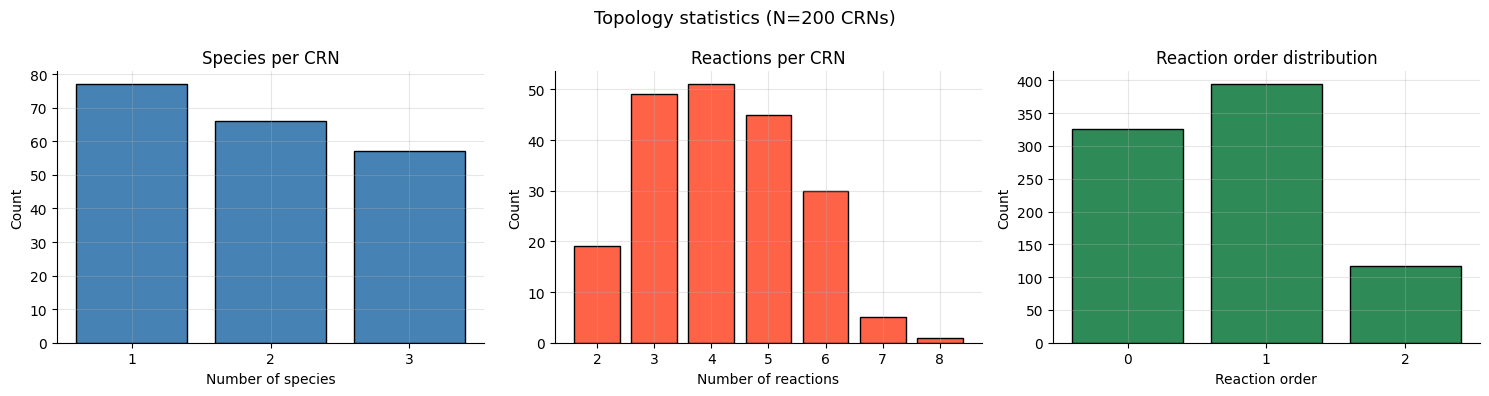

Species: min=1, max=3, mean=1.9
Reactions: min=2, max=8, mean=4.2


In [6]:
torch.manual_seed(123)
sample_crns = gen.sample_batch(200)

n_species_list = [c.n_species for c in sample_crns]
n_reactions_list = [c.n_reactions for c in sample_crns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Species distribution
vals, counts = np.unique(n_species_list, return_counts=True)
axes[0].bar(vals, counts, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Number of species")
axes[0].set_ylabel("Count")
axes[0].set_title("Species per CRN")
axes[0].set_xticks(vals)

# Reactions distribution
vals, counts = np.unique(n_reactions_list, return_counts=True)
axes[1].bar(vals, counts, color="tomato", edgecolor="black")
axes[1].set_xlabel("Number of reactions")
axes[1].set_ylabel("Count")
axes[1].set_title("Reactions per CRN")
axes[1].set_xticks(vals)

# Reaction order distribution (across all reactions in all CRNs)
all_orders = []
for crn in sample_crns:
    for rxn in crn.reactions:
        # Count total reactant molecules from stoichiometry
        consumed = (-rxn.stoichiometry).clamp(min=0).sum().item()
        # This is an approximation; the actual order comes from the propensity
        all_orders.append(int(consumed))

vals, counts = np.unique(all_orders, return_counts=True)
axes[2].bar(vals, counts, color="seagreen", edgecolor="black")
axes[2].set_xlabel("Reaction order")
axes[2].set_ylabel("Count")
axes[2].set_title("Reaction order distribution")
axes[2].set_xticks(vals)

plt.suptitle(f"Topology statistics (N={len(sample_crns)} CRNs)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Species: min={min(n_species_list)}, max={max(n_species_list)}, "
      f"mean={np.mean(n_species_list):.1f}")
print(f"Reactions: min={min(n_reactions_list)}, max={max(n_reactions_list)}, "
      f"mean={np.mean(n_reactions_list):.1f}")


## Summary

The random mass-action generator produces structurally diverse CRNs within
the constraints (1-3 species, 2-6 reactions, mass-action kinetics only). The
resulting dynamics span a wide range of behaviors including exponential
relaxation, oscillations, multi-stability, and extinction. Named topologies
(birth-death, Lotka-Volterra, etc.) are special cases that can be instantiated
from the same `MassActionTopology` abstraction.

This is the training distribution for the `mass_action_3s` experiment. The
neural surrogate must learn to produce correct stochastic trajectories for
any topology drawn from this distribution, conditioned only on the GNN
encoding of the CRN structure.
